## Analyzing 30-Day Readmissions in Diabetes Patients
### Rachael Ray Hobbs
#### 5/18/2026

In [1]:
import pandas as pd
pd.options.display.max_columns = 50

import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

This project uses the Diabetes 130-US Hospitals dataset from the UCI Machine Learning Repository, which contains 101,766 inpatient hospital encounters from 130 U.S. hospitals and integrated delivery networks between 1999 and 2008. Each record represents a patient encounter involving a diabetes diagnosis, lab testing, medication administration, and a hospital stay of 1 to 14 days. The dataset includes demographic, clinical, hospital utilization, diagnosis, medication, and readmission-related variables.

The goal of this project is to explore factors associated with hospital readmission among patients with diabetes, with particular attention to whether a patient was readmitted within 30 days of discharge. Because the data includes sensitive demographic variables such as age, gender, and race, this analysis should be interpreted carefully and used as an educational data science project rather than as a clinical decision-making tool.

Dataset citation: Clore, J., Cios, K., DeShazo, J., & Strack, B. (2014). Diabetes 130-US Hospitals for Years 1999-2008 [Dataset](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008). UCI Machine Learning Repository.

In [2]:
diabetic_df = pd.read_csv(
    "..\data\diabetic_data.csv",
    na_values="?",
    low_memory=False
)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\hobbs\AppData\Local\Temp\ipykernel_49880\2586471436.py:2: SyntaxWarning: invalid escape sequence '\d'
  "..\data\diabetic_data.csv",


In [3]:
diabetic_df.shape

(101766, 50)

In [4]:
diabetic_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [5]:
diabetic_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
na_perc = diabetic_df.isna().mean() * 100

remove_col = na_perc[na_perc > 35].index

diabetic_df = diabetic_df.drop(columns=remove_col).copy()

remove_col

Index(['weight', 'payer_code', 'medical_specialty', 'max_glu_serum',
       'A1Cresult'],
      dtype='object')

In [7]:
na_col = na_perc[(na_perc > 0) & (na_perc < 35)]

na_col

race      2.233555
diag_1    0.020636
diag_2    0.351787
diag_3    1.398306
dtype: float64

In [8]:
cols_to_impute = ["race", "diag_1", "diag_2", "diag_3"]

diabetic_df[cols_to_impute] = diabetic_df[cols_to_impute].fillna("Unknown")

In [9]:
diabetic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   admission_type_id         101766 non-null  int64 
 6   discharge_disposition_id  101766 non-null  int64 
 7   admission_source_id       101766 non-null  int64 
 8   time_in_hospital          101766 non-null  int64 
 9   num_lab_procedures        101766 non-null  int64 
 10  num_procedures            101766 non-null  int64 
 11  num_medications           101766 non-null  int64 
 12  number_outpatient         101766 non-null  int64 
 13  number_emergency          101766 non-null  int64 
 14  numb

In [10]:
id_cols = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

mapping_file = "..\data\IDS_mapping.xlsx"

for col in id_cols:
    mapping_df = pd.read_excel(mapping_file, sheet_name=col)

    # Make both sides the same type
    mapping_df[col] = mapping_df[col].astype(str).str.strip()
    diabetic_df[col] = diabetic_df[col].astype(str).str.strip()

    mapper = dict(zip(mapping_df[col], mapping_df["description"]))

    diabetic_df[col] = diabetic_df[col].map(mapper)

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
C:\Users\hobbs\AppData\Local\Temp\ipykernel_49880\2298574555.py:7: SyntaxWarning: invalid escape sequence '\d'
  mapping_file = "..\data\IDS_mapping.xlsx"


In [11]:
diabetic_df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,Not Mapped,Physician Referral,1,41,0,1,0,0,0,250.83,Unknown,Unknown,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),Emergency,Discharged to home,Emergency Room,3,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),Emergency,Discharged to home,Emergency Room,2,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),Emergency,Discharged to home,Emergency Room,2,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),Emergency,Discharged to home,Emergency Room,1,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


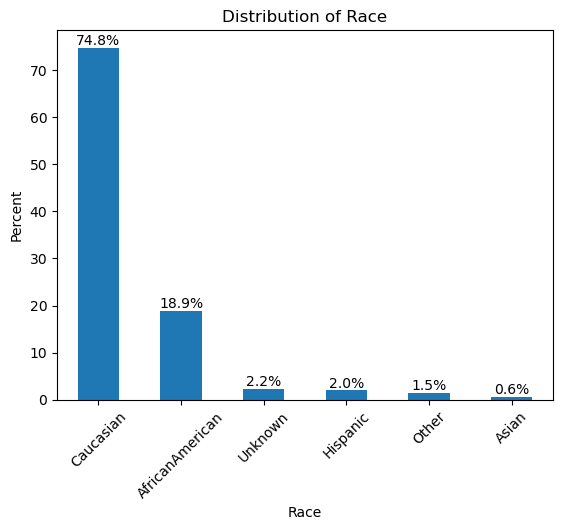

In [12]:
race_pct = diabetic_df["race"].value_counts(normalize=True) * 100

ax = race_pct.plot(kind="bar")

plt.xlabel("Race")
plt.ylabel("Percent")
plt.title("Distribution of Race")
plt.xticks(rotation=45)

for i, pct in enumerate(race_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.show()

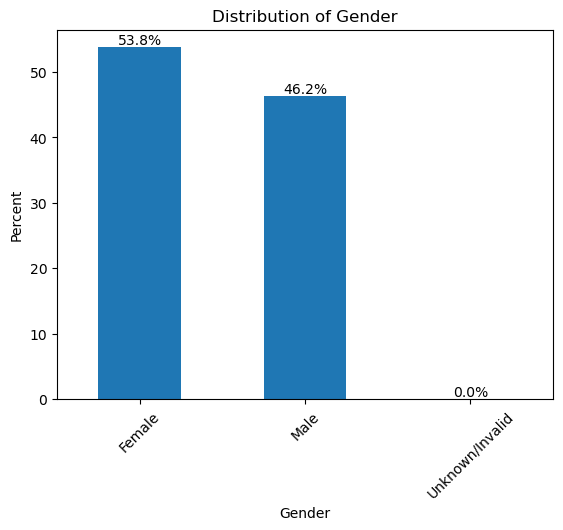

In [13]:
gender_pct = diabetic_df["gender"].value_counts(normalize=True)*100

ax = gender_pct.plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Percent")
plt.title("Distribution of Gender")
plt.xticks(rotation=45)

for i, pct in enumerate(gender_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )
plt.show()

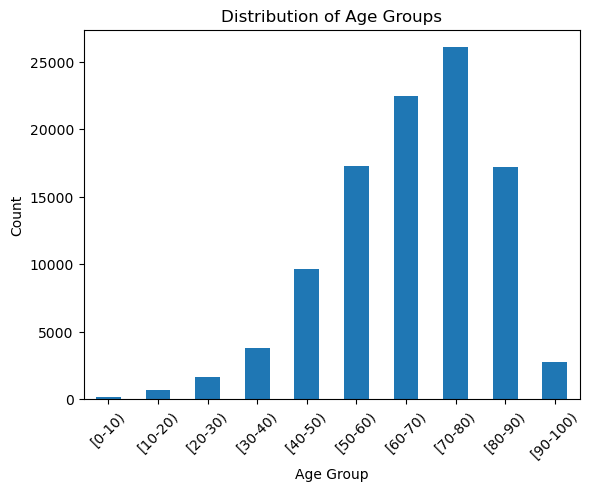

In [14]:
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"
]

diabetic_df["age"].value_counts().reindex(age_order).plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Count")
plt.title("Distribution of Age Groups")
plt.xticks(rotation=45)
plt.show()

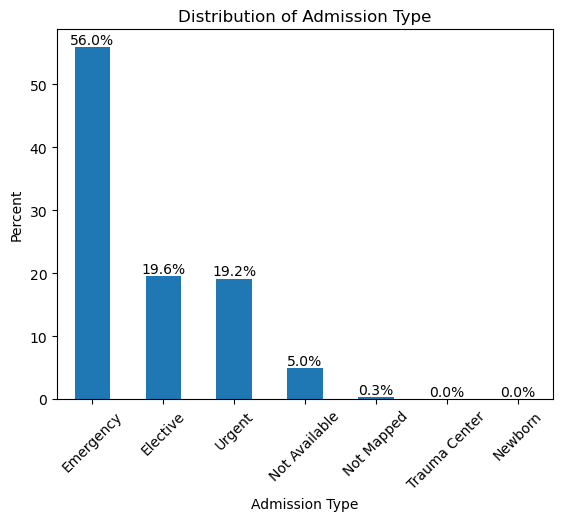

In [15]:
admiss_pct = diabetic_df["admission_type_id"].value_counts(normalize=True)*100

ax = admiss_pct.plot(kind="bar")

plt.xlabel("Admission Type")
plt.ylabel("Percent")
plt.title("Distribution of Admission Type")
plt.xticks(rotation=45)

for i, pct in enumerate(admiss_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )
plt.show()

In [16]:
discharge_pct = (
    diabetic_df["discharge_disposition_id"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

discharge_pct.columns = ["discharge_disposition_id", "percent"]

discharge_pct

,discharge_disposition_id,percent
0,Discharged to home,61.42
1,Discharged/transferred to SNF,14.23
2,Discharged/transferred to home with home healt...,13.16
3,Discharged/transferred to another short term h...,2.17
4,Discharged/transferred to another rehab fac in...,2.03
5,Expired,1.67
6,Discharged/transferred to another type of inpa...,1.21
7,Not Mapped,1.01
8,Discharged/transferred to ICF,0.83
9,Left AMA,0.64


In [17]:
admin_source_pct = (
    diabetic_df["admission_source_id"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

admin_source_pct.columns = ["admission_source_id", "percent"]

admin_source_pct


,admission_source_id,percent
0,Emergency Room,60.53
1,Physician Referral,31.13
2,Transfer from a hospital,3.36
3,Transfer from another health care facility,2.38
4,Clinic Referral,1.16
5,Transfer from a Skilled Nursing Facility (SNF),0.90
6,HMO Referral,0.20
7,Not Mapped,0.17
8,Not Available,0.13
9,Court/Law Enforcement,0.02


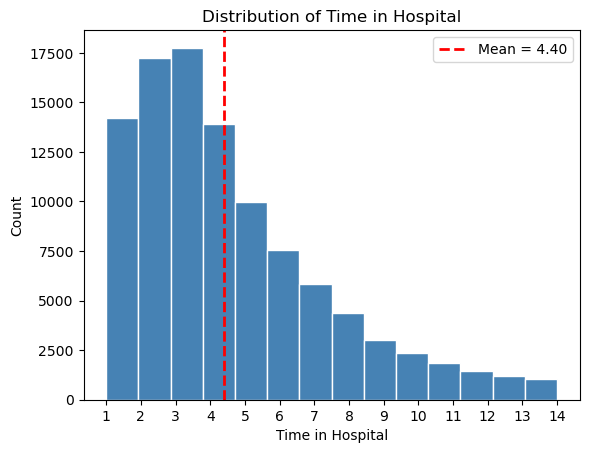

In [18]:
mean_hos = diabetic_df["time_in_hospital"].mean()

plt.hist(diabetic_df["time_in_hospital"], color="steelblue", edgecolor="white", bins=14)

plt.axvline(mean_hos, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_hos:.2f}")

plt.xlabel("Time in Hospital")
plt.ylabel("Count")
plt.title("Distribution of Time in Hospital")
plt.xticks(range(1, 15))
plt.legend()
plt.show()

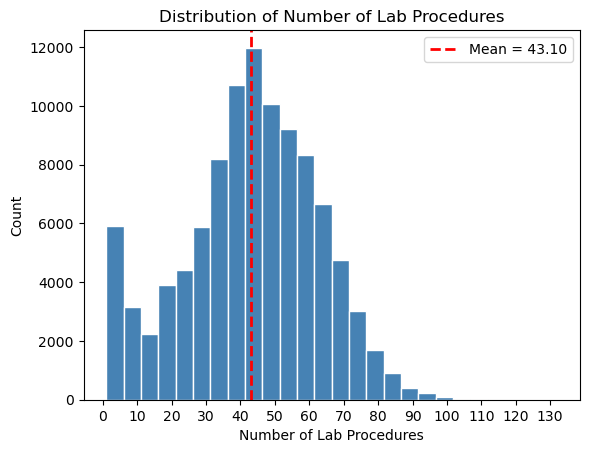

In [19]:
mean_proc = diabetic_df["num_lab_procedures"].mean()

plt.hist(diabetic_df["num_lab_procedures"], color="steelblue", edgecolor="white", bins=26)

plt.axvline(mean_proc, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_proc:.2f}")

plt.xlabel("Number of Lab Procedures")
plt.ylabel("Count")
plt.title("Distribution of Number of Lab Procedures")
plt.xticks(range(0, 131, 10))
plt.legend()
plt.show()

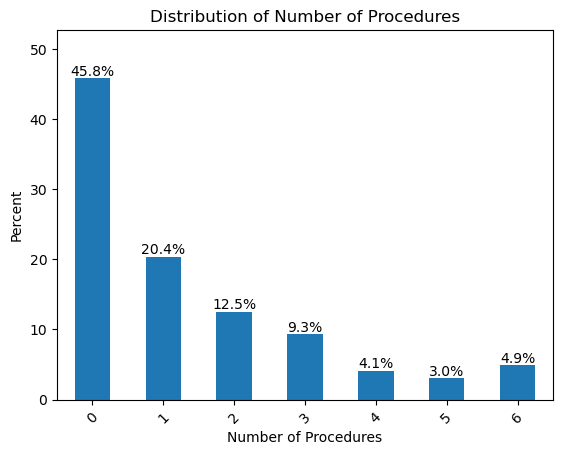

In [20]:
proc_pct = (
    diabetic_df["num_procedures"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

ax = proc_pct.plot(kind="bar")

plt.xlabel("Number of Procedures")
plt.ylabel("Percent")
plt.title("Distribution of Number of Procedures")
plt.xticks(rotation=45)

for i, pct in enumerate(proc_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, proc_pct.max() * 1.15)
plt.show()

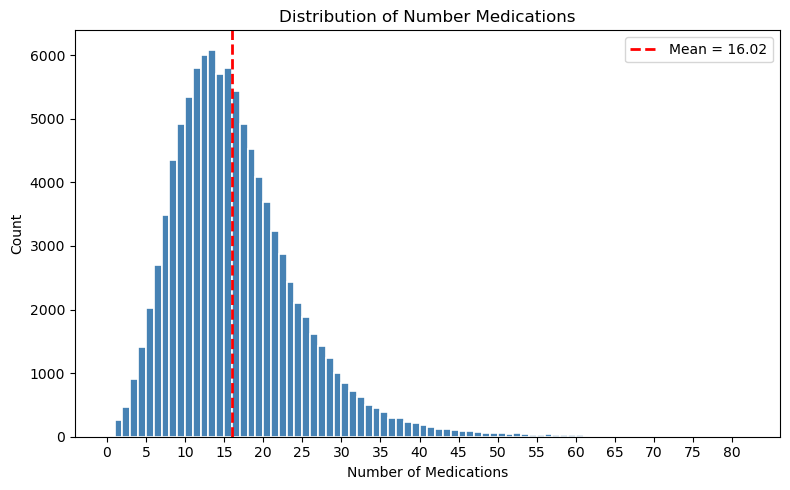

In [21]:
mean_meds = diabetic_df["num_medications"].mean()

plt.figure(figsize=(8, 5))

plt.hist(
    diabetic_df["num_medications"],
    bins= range(0, diabetic_df["num_medications"].max() + 2),
    color="steelblue",
    edgecolor="white",
    linewidth=1.2
)

plt.axvline(
    mean_meds,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_meds:.2f}"
)

plt.xlabel("Number of Medications")
plt.ylabel("Count")
plt.title("Distribution of Number Medications")
plt.xticks(range(0, diabetic_df["num_medications"].max() + 1, 5))
plt.legend()
plt.tight_layout()
plt.show()

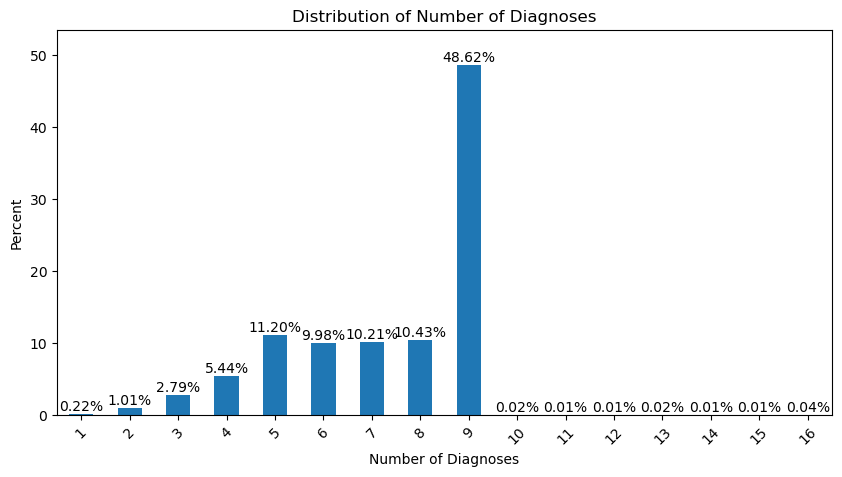

In [22]:


diag_pct = (
    diabetic_df["number_diagnoses"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

plt.figure(figsize=(10, 5))
ax = diag_pct.plot(kind="bar")

plt.xlabel("Number of Diagnoses")
plt.ylabel("Percent")
plt.title("Distribution of Number of Diagnoses")
plt.xticks(rotation=45)

for i, pct in enumerate(diag_pct):
    ax.text(
        i,
        pct,
        f"{pct:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, diag_pct.max() * 1.1)
plt.show()

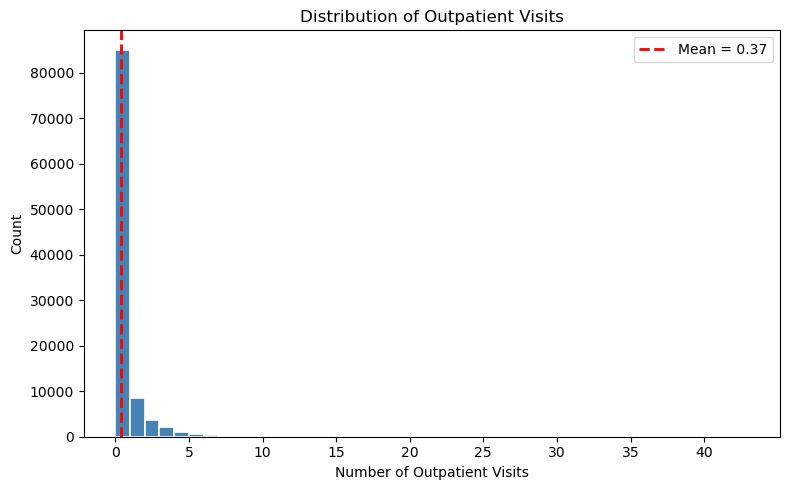

In [23]:
mean_out = diabetic_df["number_outpatient"].mean()

plt.figure(figsize=(8, 5))

plt.hist(
    diabetic_df["number_outpatient"],
    bins= range(0, diabetic_df["number_outpatient"].max() + 2),
    color="steelblue",
    edgecolor="white",
    linewidth=1.2
)

plt.axvline(
    mean_out,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_out:.2f}"
)

plt.xlabel("Number of Outpatient Visits")
plt.ylabel("Count")
plt.title("Distribution of Outpatient Visits")
plt.xticks(range(0, diabetic_df["number_outpatient"].max() + 1, 5))
plt.legend()
plt.tight_layout()
plt.show()

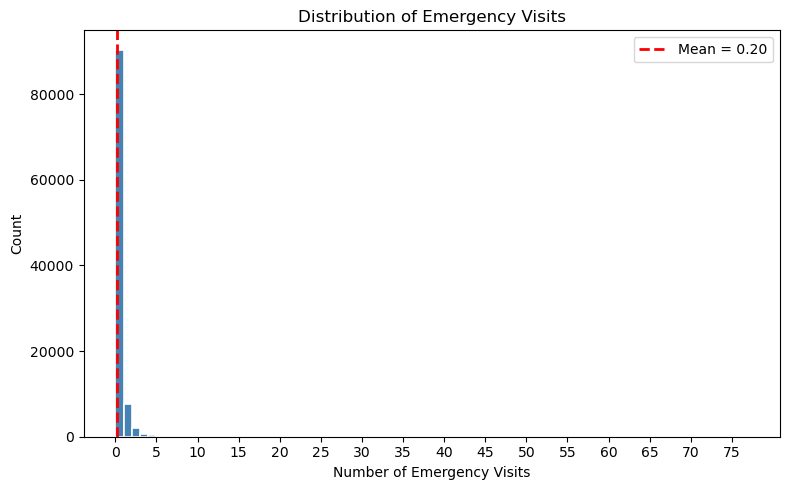

In [24]:
mean_in = diabetic_df["number_emergency"].mean()

plt.figure(figsize=(8, 5))

plt.hist(
    diabetic_df["number_emergency"],
    bins= range(0, diabetic_df["number_emergency"].max() + 2),
    color="steelblue",
    edgecolor="white",
    linewidth=1.2
)

plt.axvline(
    mean_in,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_in:.2f}"
)

plt.xlabel("Number of Emergency Visits")
plt.ylabel("Count")
plt.title("Distribution of Emergency Visits")
plt.xticks(range(0, diabetic_df["number_emergency"].max() + 1, 5))
plt.legend()
plt.tight_layout()
plt.show()

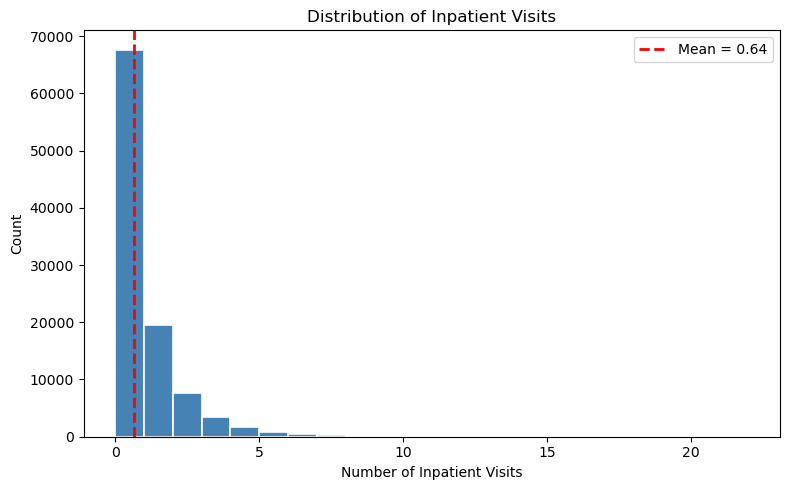

In [25]:
mean_in = diabetic_df["number_inpatient"].mean()

plt.figure(figsize=(8, 5))

plt.hist(
    diabetic_df["number_inpatient"],
    bins= range(0, diabetic_df["number_inpatient"].max() + 2),
    color="steelblue",
    edgecolor="white",
    linewidth=1.2
)

plt.axvline(
    mean_in,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_in:.2f}"
)

plt.xlabel("Number of Inpatient Visits")
plt.ylabel("Count")
plt.title("Distribution of Inpatient Visits")
plt.xticks(range(0, diabetic_df["number_inpatient"].max() + 1, 5))
plt.legend()
plt.tight_layout()
plt.show()

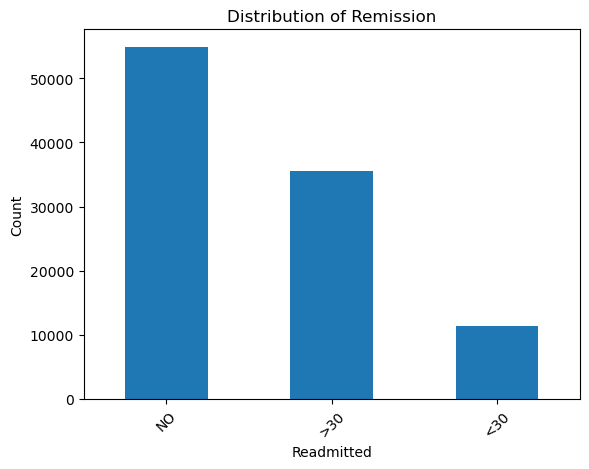

In [26]:
diabetic_df["readmitted"].value_counts().plot(kind="bar")

plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.title("Distribution of Remission")
plt.xticks(rotation=45)
plt.show()

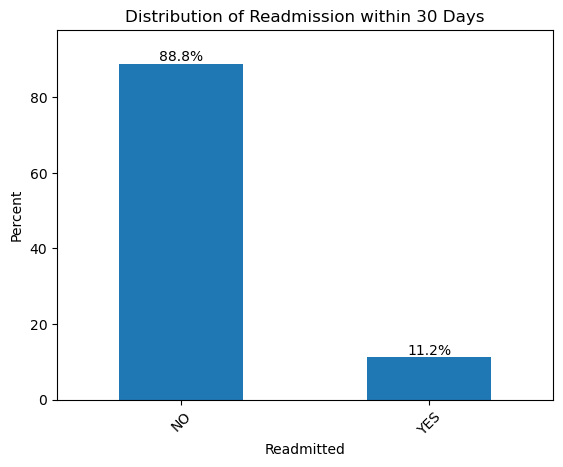

In [27]:
diabetic_df["readmitted_30"] = np.where(
    diabetic_df["readmitted"] == "<30",
    "YES",
    "NO"
)

readmitt_pct = diabetic_df["readmitted_30"].value_counts(normalize=True) * 100

ax = readmitt_pct.plot(kind="bar")

plt.xlabel("Readmitted")
plt.ylabel("Percent")
plt.title("Distribution of Readmission within 30 Days")
plt.xticks(rotation=45)

for i, pct in enumerate(readmitt_pct):
    ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, readmitt_pct.max() * 1.1)
plt.show()

In [28]:
analysis_df = diabetic_df.copy()

age_mapping = {
    "[0-10)": 0,
    "[10-20)": 1,
    "[20-30)": 2,
    "[30-40)": 3,
    "[40-50)": 4,
    "[50-60)": 5,
    "[60-70)": 6,
    "[70-80)": 7,
    "[80-90)": 8,
    "[90-100)": 9
}

readmitted_mapping = {
    "NO": 0,
    "YES": 1
}

analysis_df["readmitted_30_encoded"] = analysis_df["readmitted_30"].map(readmitted_mapping)

analysis_df["age_encoded"] = analysis_df["age"].map(age_mapping)

categorical_columns = ["race", "gender", "change", "diabetesMed"]

encoded_df = pd.get_dummies(
    analysis_df[categorical_columns],
    drop_first=True,
    dtype=int
)

numeric_df = analysis_df.select_dtypes(include="number").drop(
    columns=["encounter_id", "patient_nbr"],
    errors="ignore"
)

correlation_df = pd.concat([numeric_df, encoded_df], axis=1)

correlation_matrix = correlation_df.corr()

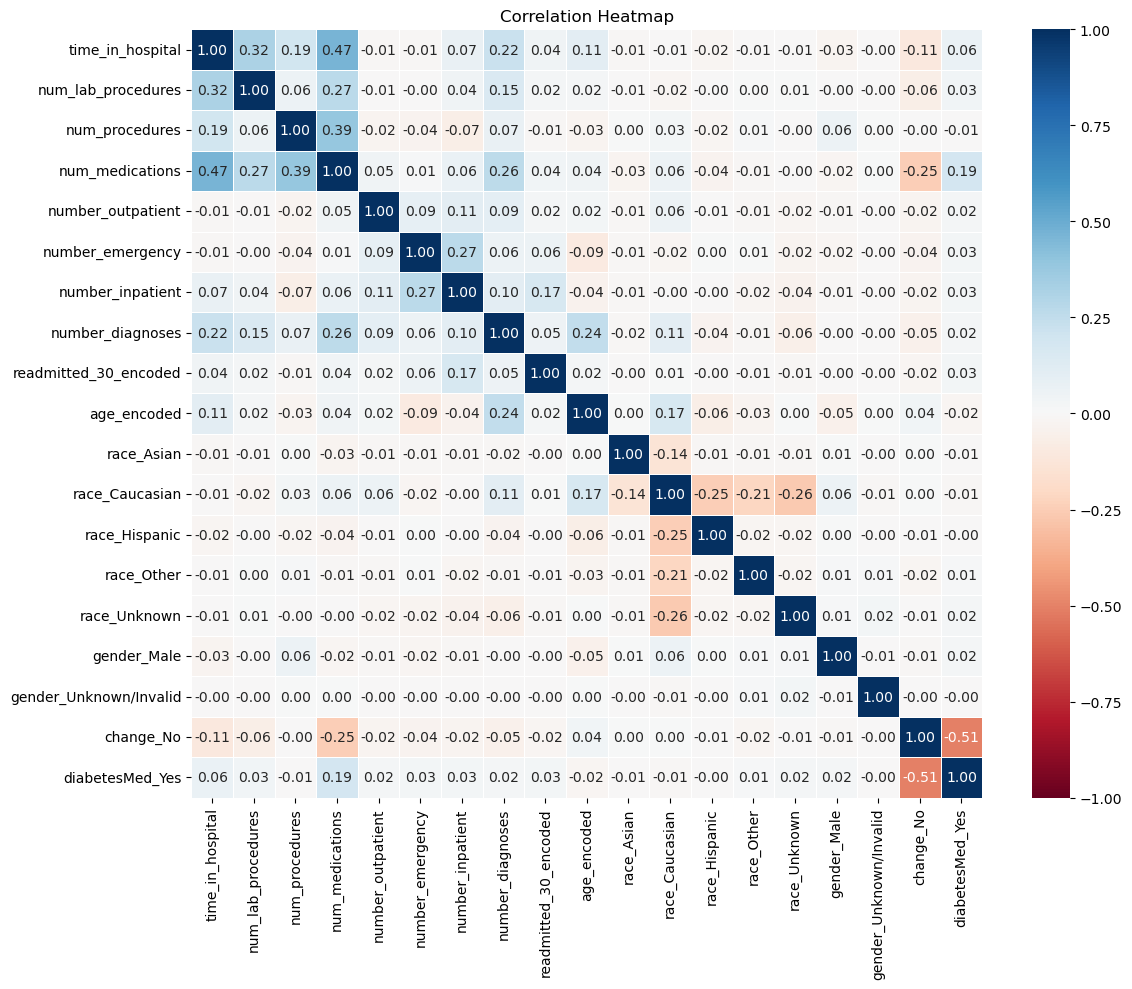

In [29]:

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="RdBu",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()